# 📈 Notebook 03 — Prophet: Previsão de Volume de Incidentes
## Predictfy × Locaweb — FIAP Challenge 2026

**Objetivo:** Treinar modelos de série temporal para prever o volume de incidentes KPI nos horizontes D+1 e D+7, separado por prioridade (P2 e P3).

**Modelos a treinar:** `prophet_total`, `prophet_p2`, `prophet_p3`

**Output:** `outputs/previsoes_volume.json` — consumido pelo dashboard React e pelo notebook 07 (Projeção de KPI)

> ⚠️ Este notebook prevê **volume de incidentes**, não violações de OLA.  
> A pergunta "quantos desses incidentes vão violar?" é responsabilidade do notebook 04 (XGBoost).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import holidays
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ Imports concluídos')

/opt/homebrew/Caskroom/miniconda/base/envs/predictfy-locaweb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


✅ Imports concluídos


In [2]:
# Carregar dataset bruto — não o parquet, precisamos da série completa
raw = pd.read_excel('../data/raw/LW-DATASET.xlsx')

# Filtrar subset KPI
kpi = raw[raw['Entrou para KPI?'] == 'SIM'].copy()
kpi['data'] = pd.to_datetime(kpi['Aberto']).dt.normalize()  # só a data, sem hora

# Série 1: volume diário total (P2 + P3)
serie_total = (
    kpi.groupby('data')
    .size()
    .reset_index(name='y')
    .rename(columns={'data': 'ds'})
)

# Série 2: só P2
serie_p2 = (
    kpi[kpi['Prioridade'] == '2 - Alta']
    .groupby('data')
    .size()
    .reset_index(name='y')
    .rename(columns={'data': 'ds'})
)

# Série 3: só P3
serie_p3 = (
    kpi[kpi['Prioridade'] == '3 - Média']
    .groupby('data')
    .size()
    .reset_index(name='y')
    .rename(columns={'data': 'ds'})
)

print('Série total:', serie_total.shape, '| range:', serie_total.ds.min().date(), 'a', serie_total.ds.max().date())
print('Série P2:   ', serie_p2.shape,    '| range:', serie_p2.ds.min().date(), 'a', serie_p2.ds.max().date())
print('Série P3:   ', serie_p3.shape,    '| range:', serie_p3.ds.min().date(), 'a', serie_p3.ds.max().date())
print()
print('Média diária — Total:', round(serie_total.y.mean(), 1),
      '| P2:', round(serie_p2.y.mean(), 1),
      '| P3:', round(serie_p3.y.mean(), 1))

Série total: (607, 2) | range: 2023-01-02 a 2025-12-31
Série P2:    (365, 2) | range: 2025-01-01 a 2025-12-31
Série P3:    (607, 2) | range: 2023-01-02 a 2025-12-31

Média diária — Total: 42.2 | P2: 14.1 | P3: 33.7


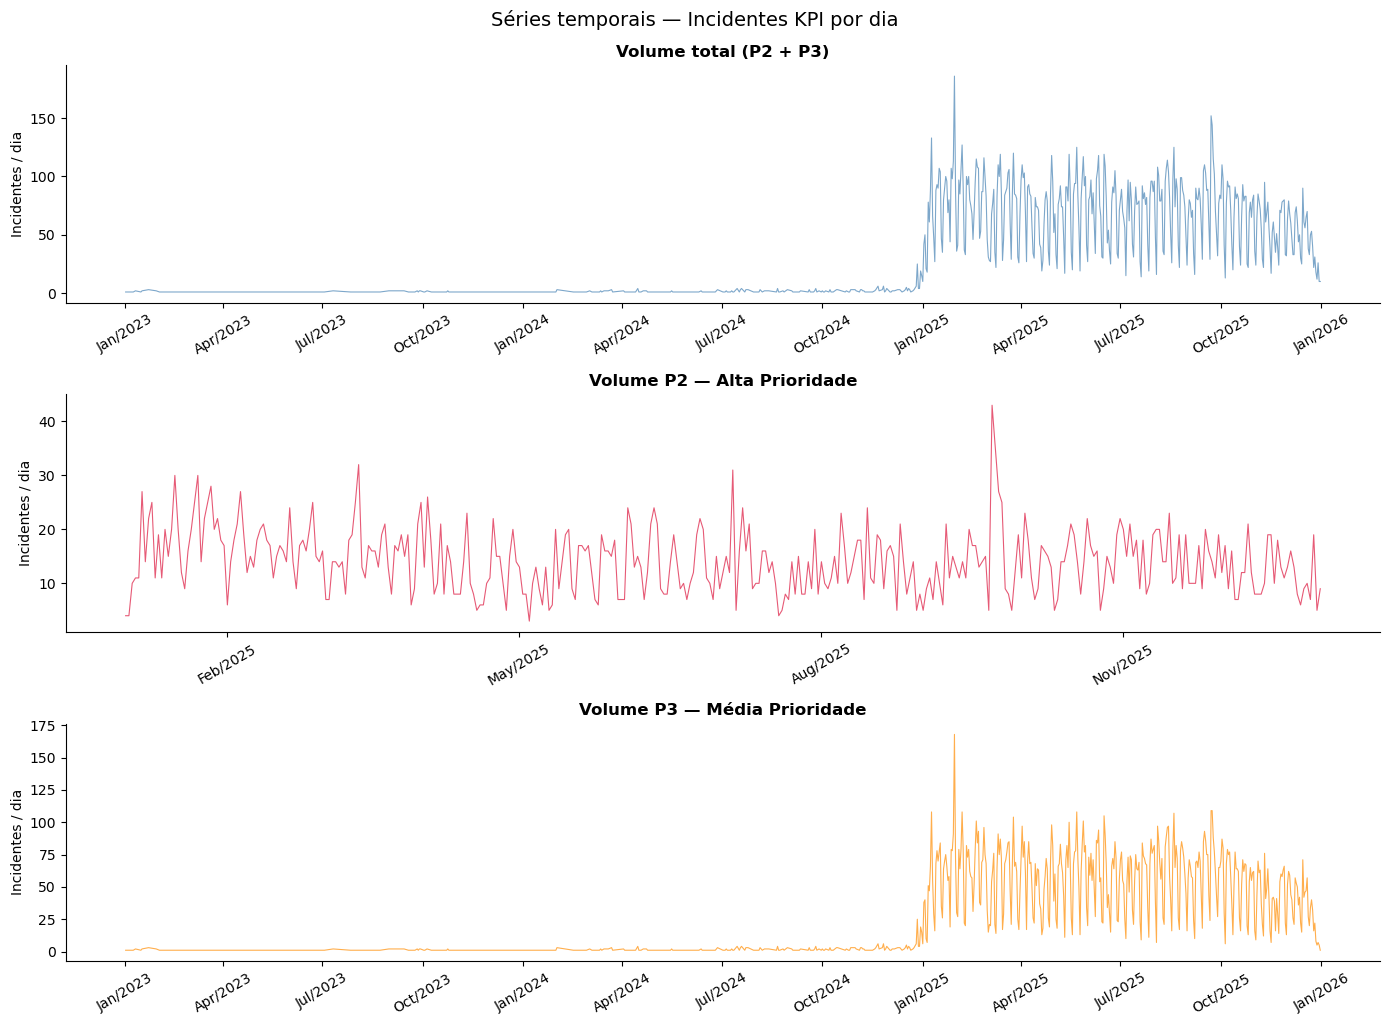

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, serie, titulo, cor in zip(
    axes,
    [serie_total, serie_p2, serie_p3],
    ['Volume total (P2 + P3)', 'Volume P2 — Alta Prioridade', 'Volume P3 — Média Prioridade'],
    ['steelblue', 'crimson', 'darkorange']
):
    ax.plot(serie.ds, serie.y, color=cor, linewidth=0.8, alpha=0.7)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Incidentes / dia')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.suptitle('Séries temporais — Incidentes KPI por dia', y=1.02, fontsize=14)
plt.show()

In [4]:
# Usar apenas 2025 — regime operacional atual
DATA_INICIO = '2025-01-01'
DATA_FIM = '2025-12-31'

def preparar_serie(serie, inicio=DATA_INICIO, fim=DATA_FIM):
    """
    Filtra pelo período e preenche dias sem incidente com zero.
    Prophet precisa de uma linha para cada dia do período.
    """
    # Criar calendário completo do período
    calendario = pd.DataFrame({
        'ds': pd.date_range(start=inicio, end=fim, freq='D')
    })
    # Merge com a série real — dias ausentes viram zero
    serie_completa = calendario.merge(serie, on='ds', how='left')
    serie_completa['y'] = serie_completa['y'].fillna(0)
    return serie_completa

serie_total_2025 = preparar_serie(serie_total)
serie_p2_2025    = preparar_serie(serie_p2)
serie_p3_2025    = preparar_serie(serie_p3)

for nome, s in [('Total', serie_total_2025), ('P2', serie_p2_2025), ('P3', serie_p3_2025)]:
    zeros = (s['y'] == 0).sum()
    print(f'{nome}: {len(s)} dias | zeros={zeros} ({zeros/len(s)*100:.0f}%) | média={s.y.mean():.1f} | max={s.y.max()}')

Total: 365 dias | zeros=0 (0%) | média=68.9 | max=186
P2: 365 dias | zeros=0 (0%) | média=14.1 | max=43
P3: 365 dias | zeros=0 (0%) | média=54.8 | max=168


In [5]:
# Gerar feriados brasileiros de 2025
br_holidays = holidays.Brazil(years=2025)

# Converter para o formato que o Prophet espera:
# DataFrame com colunas 'ds' e 'holiday'
feriados_df = pd.DataFrame([
    {'ds': pd.Timestamp(data), 'holiday': nome}
    for data, nome in br_holidays.items()
])
feriados_df = feriados_df.sort_values('ds').reset_index(drop=True)

print(f'Feriados brasileiros em 2025: {len(feriados_df)}')
print()
print(feriados_df.to_string(index=False))

Feriados brasileiros em 2025: 10

        ds                                   holiday
2025-01-01              Universal Fraternization Day
2025-04-18                               Good Friday
2025-04-21                           Tiradentes' Day
2025-05-01                              Worker's Day
2025-09-07                          Independence Day
2025-10-12                     Our Lady of Aparecida
2025-11-02                            All Souls' Day
2025-11-15                 Republic Proclamation Day
2025-11-20 National Day of Zumbi and Black Awareness
2025-12-25                             Christmas Day


In [6]:
# Feriados nacionais obrigatórios (já detectados)
feriados_nacionais = feriados_df.copy()

# Datas que se comportam como feriado na operação
# mas não são feriados nacionais pela lei
feriados_extras = pd.DataFrame([
    # Carnaval 2025 (ponto facultativo — operação reduzida)
    {'ds': pd.Timestamp('2025-03-03'), 'holiday': 'Carnaval — Segunda'},
    {'ds': pd.Timestamp('2025-03-04'), 'holiday': 'Carnaval — Terça'},
    {'ds': pd.Timestamp('2025-03-05'), 'holiday': 'Carnaval — Quarta de Cinzas'},
    # Corpus Christi (ponto facultativo federal)
    {'ds': pd.Timestamp('2025-06-19'), 'holiday': 'Corpus Christi'},
    # Véspera de Natal e Ano Novo (operação reduzida historicamente)
    {'ds': pd.Timestamp('2025-12-24'), 'holiday': 'Véspera de Natal'},
    {'ds': pd.Timestamp('2025-12-31'), 'holiday': 'Véspera de Ano Novo'},
])

# Juntar tudo
feriados_completo = pd.concat([feriados_nacionais, feriados_extras], ignore_index=True)
feriados_completo = feriados_completo.sort_values('ds').reset_index(drop=True)

print(f'Feriados nacionais:  {len(feriados_nacionais)}')
print(f'Feriados extras:     {len(feriados_extras)}')
print(f'Total para Prophet:  {len(feriados_completo)}')
print()
print(feriados_completo.to_string(index=False))

Feriados nacionais:  10
Feriados extras:     6
Total para Prophet:  16

        ds                                   holiday
2025-01-01              Universal Fraternization Day
2025-03-03                        Carnaval — Segunda
2025-03-04                          Carnaval — Terça
2025-03-05               Carnaval — Quarta de Cinzas
2025-04-18                               Good Friday
2025-04-21                           Tiradentes' Day
2025-05-01                              Worker's Day
2025-06-19                            Corpus Christi
2025-09-07                          Independence Day
2025-10-12                     Our Lady of Aparecida
2025-11-02                            All Souls' Day
2025-11-15                 Republic Proclamation Day
2025-11-20 National Day of Zumbi and Black Awareness
2025-12-24                          Véspera de Natal
2025-12-25                             Christmas Day
2025-12-31                       Véspera de Ano Novo


In [7]:
# ── Modelo 1: Volume total (P2 + P3) ─────────────────────────────────────────

m_total = Prophet(
    yearly_seasonality=True,   # aprende padrão anual (verão, fim de ano, etc.)
    weekly_seasonality=True,   # aprende padrão semanal (seg vs dom)
    daily_seasonality=False,   # não faz sentido — dado já é agregado por dia
    holidays=feriados_completo,
    seasonality_mode='multiplicative',  # picos crescem proporcionalmente ao nível
    changepoint_prior_scale=0.05,       # quão flexível é a tendência (0.05 = conservador)
    holidays_prior_scale=10.0,          # quanto o modelo confia nos feriados
)

m_total.fit(serie_total_2025)

# Gerar datas futuras: 7 dias além do último dia do histórico
futuro_total = m_total.make_future_dataframe(periods=7, freq='D')
prev_total = m_total.predict(futuro_total)

print('✅ Modelo total treinado')
print(f'   Histórico: {len(serie_total_2025)} dias')
print(f'   Previsão gerada até: {prev_total.ds.max().date()}')
print()
# Mostrar os 7 dias de previsão
print('Previsão D+1 a D+7:')
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
print(prev_total[cols].tail(7).to_string(index=False))

01:24:37 - cmdstanpy - INFO - Chain [1] start processing
01:24:37 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo total treinado
   Histórico: 365 dias
   Previsão gerada até: 2026-01-07

Previsão D+1 a D+7:
        ds      yhat  yhat_lower  yhat_upper
2026-01-01 45.497694   29.306503   62.303853
2026-01-02 37.320124   21.631415   54.137106
2026-01-03 11.778358   -4.888855   29.039981
2026-01-04  1.843309  -14.498835   17.659352
2026-01-05 44.165202   28.309013   60.054971
2026-01-06 49.972749   33.632392   65.396086
2026-01-07 50.022775   32.882542   67.013851


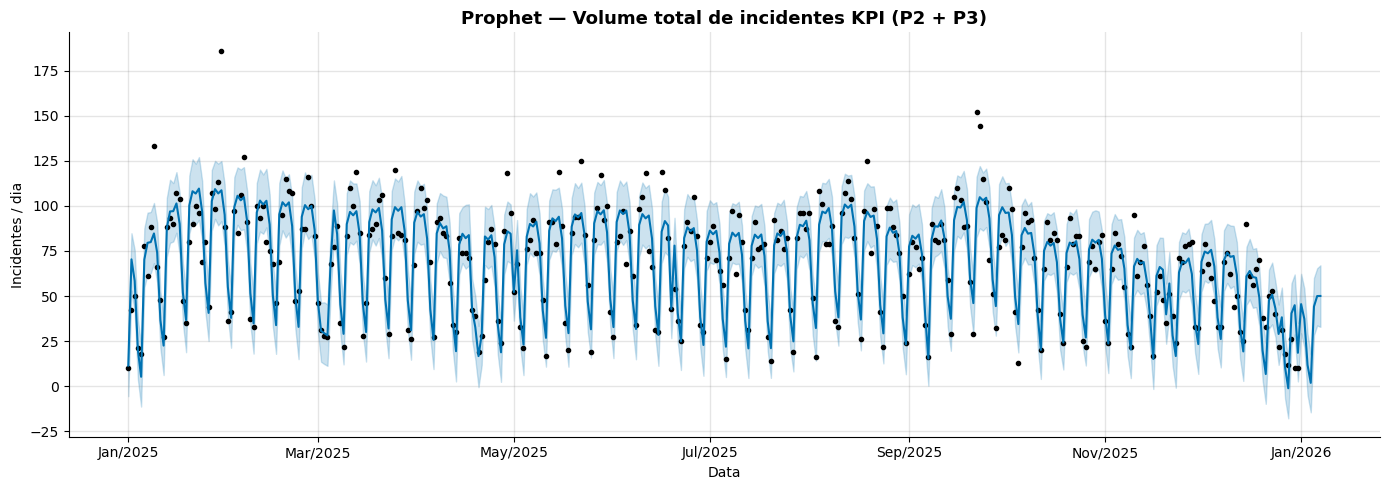

In [8]:
fig = m_total.plot(prev_total, figsize=(14, 5))
ax = fig.gca()
ax.set_title('Prophet — Volume total de incidentes KPI (P2 + P3)', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Incidentes / dia')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.tight_layout()
plt.show()

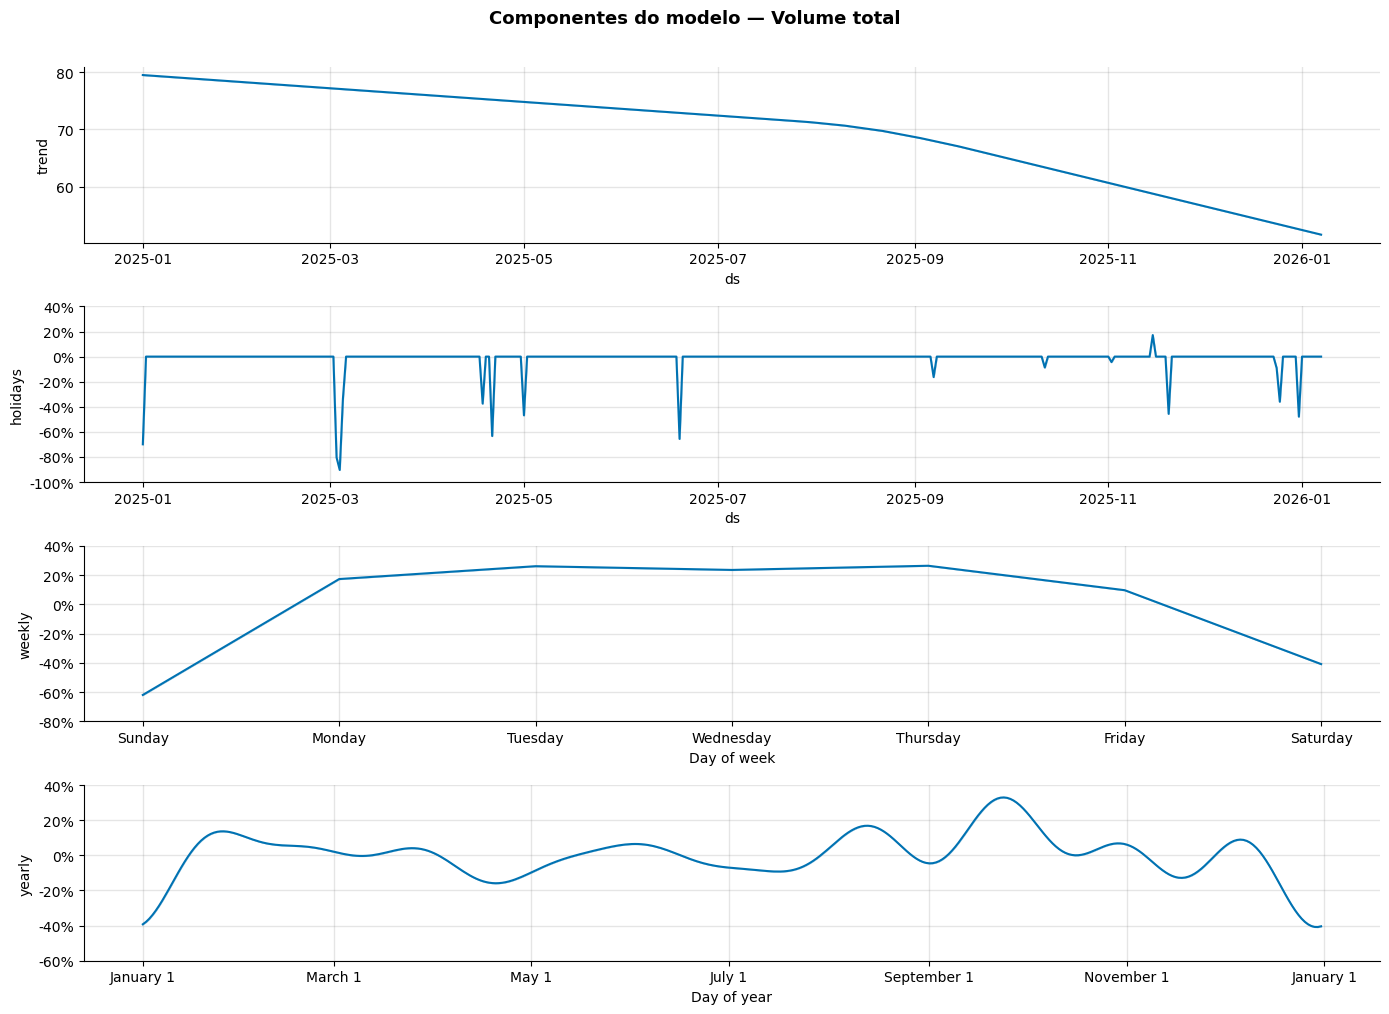

In [9]:
fig2 = m_total.plot_components(prev_total, figsize=(14, 10))
plt.suptitle('Componentes do modelo — Volume total', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

01:24:37 - cmdstanpy - INFO - Chain [1] start processing
01:24:37 - cmdstanpy - INFO - Chain [1] done processing


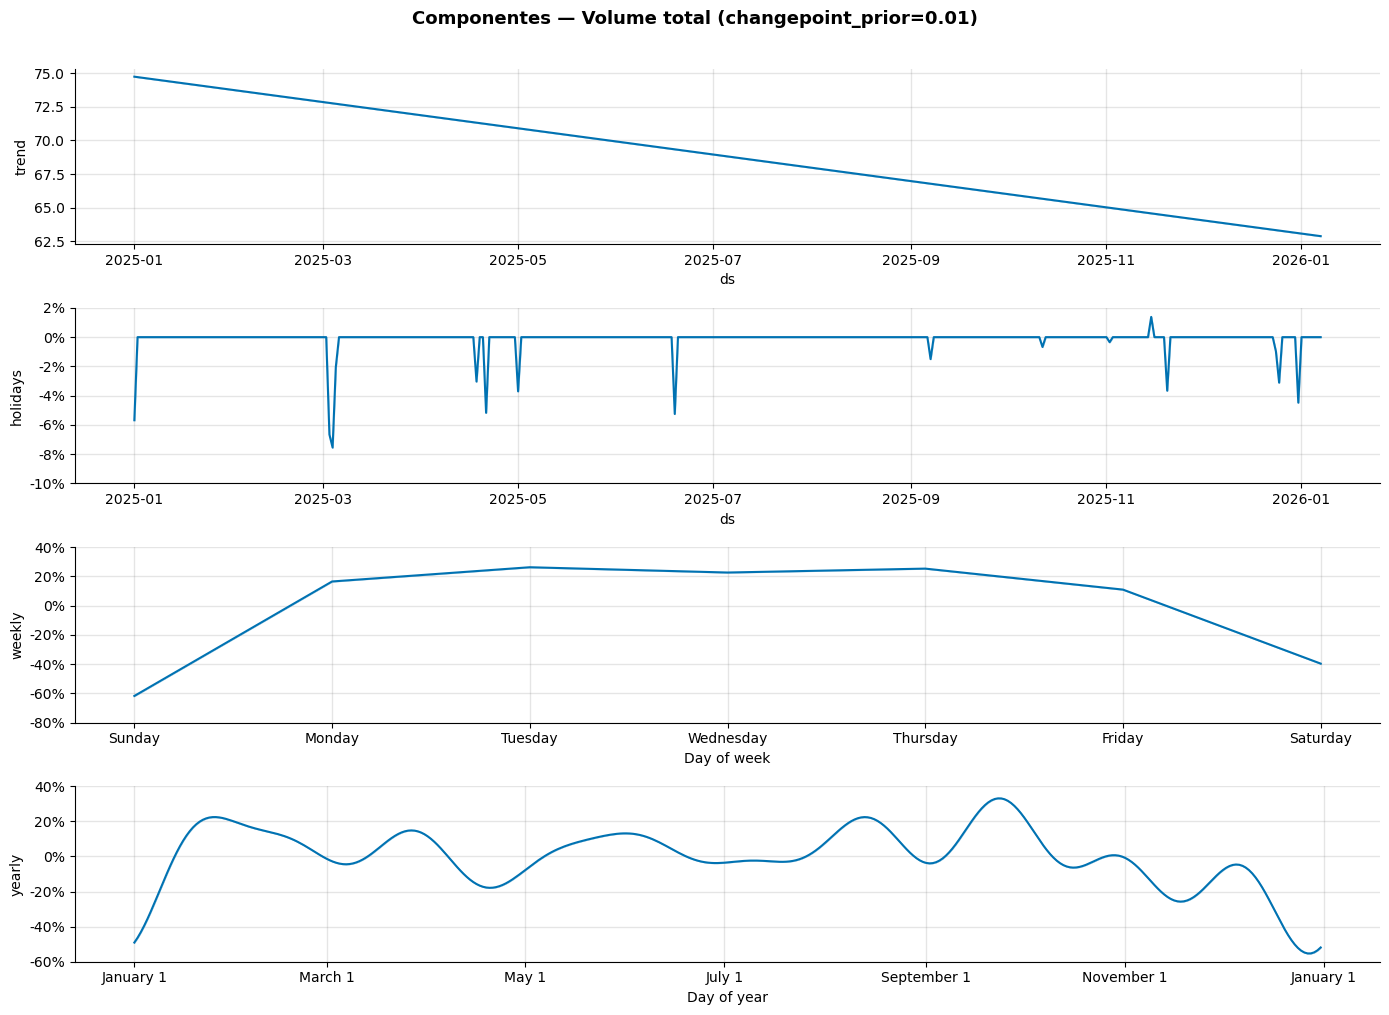

Previsão D+1 a D+7:
        ds      yhat  yhat_lower  yhat_upper
2026-01-01 47.677708   28.849599   65.910523
2026-01-02 40.278399   20.738969   58.086200
2026-01-03 10.303669   -8.194509   29.487520
2026-01-04 -1.449855  -19.723277   16.925855
2026-01-05 50.237386   30.555488   69.933493
2026-01-06 58.892796   41.197797   78.115600
2026-01-07 59.266448   40.019105   78.595558


In [10]:
m_total = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,   # era 0.05 — tendência mais plana
    holidays_prior_scale=3.0,
)

m_total.fit(serie_total_2025)
futuro_total = m_total.make_future_dataframe(periods=7, freq='D')
prev_total = m_total.predict(futuro_total)

# Plotar componentes novamente para comparar
fig = m_total.plot_components(prev_total, figsize=(14, 10))
plt.suptitle('Componentes — Volume total (changepoint_prior=0.01)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Previsão D+1 a D+7:')
print(prev_total[['ds','yhat','yhat_lower','yhat_upper']].tail(7).to_string(index=False))

01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing


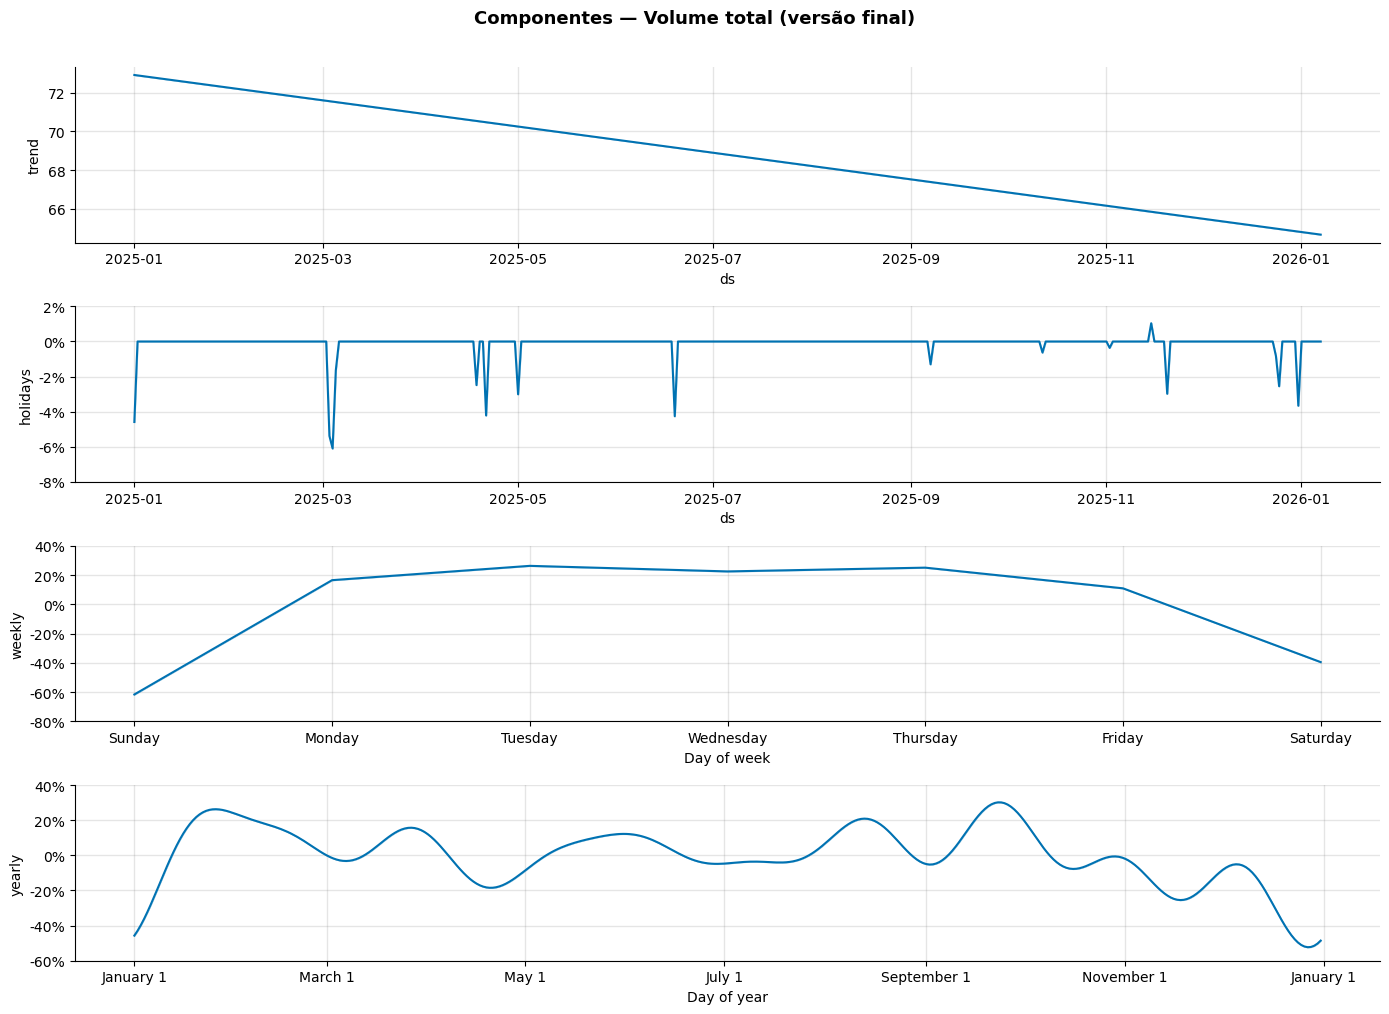

Previsão D+1 a D+7:
        ds      yhat  yhat_lower  yhat_upper
2026-01-01 51.011217   32.621785   69.138056
2026-01-02 43.585689   26.455869   63.382409
2026-01-03 12.919243   -7.654705   30.387050
2026-01-04  0.849421  -17.429887   19.593772
2026-01-05 53.860463   33.794153   70.923175
2026-01-06 62.790962   43.766952   82.415526
2026-01-07 63.049035   44.815092   81.957491


In [11]:
m_total = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,  # tendência conservadora
    holidays_prior_scale=8.0,      # feriados com efeito real — reforçado
    seasonality_prior_scale=10.0,  # sazonalidade semanal/anual com liberdade
)

m_total.fit(serie_total_2025)
futuro_total = m_total.make_future_dataframe(periods=7, freq='D')
prev_total = m_total.predict(futuro_total)

fig = m_total.plot_components(prev_total, figsize=(14, 10))
plt.suptitle('Componentes — Volume total (versão final)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Previsão D+1 a D+7:')
print(prev_total[['ds','yhat','yhat_lower','yhat_upper']].tail(7).to_string(index=False))

In [12]:
# ── Modelo P2 ─────────────────────────────────────────────────────────────────
m_p2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,
    holidays_prior_scale=8.0,
    seasonality_prior_scale=10.0,
)
m_p2.fit(serie_p2_2025)
futuro_p2 = m_p2.make_future_dataframe(periods=7, freq='D')
prev_p2 = m_p2.predict(futuro_p2)

print('✅ Modelo P2 treinado')
print(prev_p2[['ds','yhat','yhat_lower','yhat_upper']].tail(7).to_string(index=False))

print()

# ── Modelo P3 ─────────────────────────────────────────────────────────────────
m_p3 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,
    holidays_prior_scale=8.0,
    seasonality_prior_scale=10.0,
)
m_p3.fit(serie_p3_2025)
futuro_p3 = m_p3.make_future_dataframe(periods=7, freq='D')
prev_p3 = m_p3.predict(futuro_p3)

print('✅ Modelo P3 treinado')
print(prev_p3[['ds','yhat','yhat_lower','yhat_upper']].tail(7).to_string(index=False))

01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo P2 treinado
        ds      yhat  yhat_lower  yhat_upper
2026-01-01 14.729322    9.162816   20.547899
2026-01-02 12.612756    6.223263   18.743442
2026-01-03  9.935278    4.041239   15.832834
2026-01-04  9.215980    3.167205   14.898822
2026-01-05 17.157019   11.664838   23.118575
2026-01-06 17.925146   12.415989   23.514330
2026-01-07 17.935155   12.441045   23.651489

✅ Modelo P3 treinado
        ds      yhat  yhat_lower  yhat_upper
2026-01-01 34.834380   18.716050   50.393437
2026-01-02 29.471556   11.604418   47.782574
2026-01-03  2.701845  -13.961006   19.704905
2026-01-04 -8.120689  -25.215508    8.868019
2026-01-05 35.349258   17.825476   52.559865
2026-01-06 43.173401   26.886790   60.543181
2026-01-07 43.469647   27.264148   60.121244


In [13]:
from prophet.diagnostics import cross_validation, performance_metrics

# Cross-validation do modelo total
# initial: treina com os primeiros 180 dias
# period: desloca a janela a cada 30 dias
# horizon: avalia a previsão para os próximos 7 dias
cv_total = cross_validation(
    m_total,
    initial='180 days',
    period='30 days',
    horizon='7 days',
    parallel=None
)

metricas_total = performance_metrics(cv_total)

print('=== Métricas — Modelo Total ===')
print(metricas_total[['horizon','mae','rmse','mape']].to_string(index=False))

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 17.38it/s]01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 17.60it/s]01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:00<00:00, 17.09it/s]

=== Métricas — Modelo Total ===
horizon       mae      rmse     mape
 1 days 17.785295 23.724008 0.464555
 2 days 14.810016 16.845798 0.266773
 3 days 11.987242 15.705453 0.257441
 4 days 22.873406 27.272619 0.527476
 5 days 20.291409 26.244660 0.393861
 6 days 27.698342 33.370475 1.216468
 7 days 24.600848 28.489417 1.285433


In [14]:
cv_p2 = cross_validation(
    m_p2,
    initial='180 days',
    period='30 days',
    horizon='7 days',
    parallel=None
)
metricas_p2 = performance_metrics(cv_p2)
print('=== Métricas — Modelo P2 ===')
print(metricas_p2[['horizon','mae','rmse','mape']].to_string(index=False))

print()

cv_p3 = cross_validation(
    m_p3,
    initial='180 days',
    period='30 days',
    horizon='7 days',
    parallel=None
)
metricas_p3 = performance_metrics(cv_p3)
print('=== Métricas — Modelo P3 ===')
print(metricas_p3[['horizon','mae','rmse','mape']].to_string(index=False))

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 18.34it/s]01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 17.76it/s]01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:00<00:00, 17.42it/s]
Seasonality has period of 365.25 days which i

=== Métricas — Modelo P2 ===
horizon      mae      rmse     mape
 1 days 7.950323  9.269919 0.975106
 2 days 5.746216  6.814317 0.585438
 3 days 5.489436  6.918904 0.676701
 4 days 7.345502  9.080361 0.813822
 5 days 3.629145  4.467858 0.233586
 6 days 8.693604 10.295724 1.145545
 7 days 5.659796  6.361973 0.486137



  0%|          | 0/6 [00:00<?, ?it/s]01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 18.56it/s]01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 17.95it/s]01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:00<00:00, 17.72it/s]


=== Métricas — Modelo P3 ===
horizon       mae      rmse     mape
 1 days 11.802943 16.796666 0.416754
 2 days 11.607142 12.425024 0.251862
 3 days 10.489200 12.077267 0.345238
 4 days 17.027056 20.859606 0.940061
 5 days 19.617057 24.504691 1.005079
 6 days 20.273924 24.806183 1.607230
 7 days 24.316283 26.158792 8.022749


In [15]:
# Preparar série com lag_1d como regressor externo
serie_total_lag = serie_total_2025.copy()
serie_total_lag['lag_1d'] = serie_total_lag['y'].shift(1).fillna(serie_total_lag['y'].mean())

m_total_v2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,
    holidays_prior_scale=8.0,
    seasonality_prior_scale=10.0,
)
m_total_v2.add_regressor('lag_1d')
m_total_v2.fit(serie_total_lag)

# Para prever, o futuro precisa do lag_1d estimado
# Usamos o último valor real como estimativa para D+1
ultimo_valor = serie_total_lag['y'].iloc[-1]
futuro_v2 = m_total_v2.make_future_dataframe(periods=7, freq='D')
futuro_v2 = futuro_v2.merge(
    serie_total_lag[['ds','lag_1d']],
    on='ds', how='left'
)
# Dias futuros: usar média dos últimos 7 dias como estimativa do lag
media_recente = serie_total_lag['y'].tail(7).mean()
futuro_v2['lag_1d'] = futuro_v2['lag_1d'].fillna(media_recente)

prev_v2 = m_total_v2.predict(futuro_v2)

# Cross-validation para comparar
cv_v2 = cross_validation(
    m_total_v2,
    initial='180 days',
    period='30 days',
    horizon='7 days',
    parallel=None
)
metricas_v2 = performance_metrics(cv_v2)

print('=== MAE com lag_1d vs sem lag_1d ===')
print(f'{"Horizonte":<12} {"Com lag":>10} {"Sem lag":>10} {"Melhora":>10}')
for _, row in metricas_v2.iterrows():
    h = row['horizon']
    h_str = f'{h.days} days'  # converter Timedelta para string
    mae_lag = row['mae']
    mae_orig = metricas_total[metricas_total['horizon'] == h_str]['mae'].values
    if len(mae_orig):
        delta = mae_orig[0] - mae_lag
        print(f"{h_str:<12} {mae_lag:>10.2f} {mae_orig[0]:>10.2f} {delta:>+10.2f}")

01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 18.03it/s]01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:39 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 17.47it/s]01:24:39 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chai

=== MAE com lag_1d vs sem lag_1d ===
Horizonte       Com lag    Sem lag    Melhora
1 days            17.25      17.79      +0.54
2 days            10.89      14.81      +3.92
3 days            11.11      11.99      +0.88
4 days            19.11      22.87      +3.77
5 days            17.96      20.29      +2.33
6 days            19.91      27.70      +7.79
7 days            22.53      24.60      +2.07


In [16]:
# ── P2 com lag_1d ─────────────────────────────────────────────────────────────
serie_p2_lag = serie_p2_2025.copy()
serie_p2_lag['lag_1d'] = serie_p2_lag['y'].shift(1).fillna(serie_p2_lag['y'].mean())

m_p2 = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    holidays=feriados_completo, seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01, holidays_prior_scale=8.0, seasonality_prior_scale=10.0,
)
m_p2.add_regressor('lag_1d')
m_p2.fit(serie_p2_lag)

futuro_p2 = m_p2.make_future_dataframe(periods=7, freq='D')
futuro_p2 = futuro_p2.merge(serie_p2_lag[['ds','lag_1d']], on='ds', how='left')
futuro_p2['lag_1d'] = futuro_p2['lag_1d'].fillna(serie_p2_lag['y'].tail(7).mean())
prev_p2 = m_p2.predict(futuro_p2)
print('✅ P2 retreinado com lag_1d')

# ── P3 com lag_1d ─────────────────────────────────────────────────────────────
serie_p3_lag = serie_p3_2025.copy()
serie_p3_lag['lag_1d'] = serie_p3_lag['y'].shift(1).fillna(serie_p3_lag['y'].mean())

m_p3 = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    holidays=feriados_completo, seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01, holidays_prior_scale=8.0, seasonality_prior_scale=10.0,
)
m_p3.add_regressor('lag_1d')
m_p3.fit(serie_p3_lag)

futuro_p3 = m_p3.make_future_dataframe(periods=7, freq='D')
futuro_p3 = futuro_p3.merge(serie_p3_lag[['ds','lag_1d']], on='ds', how='left')
futuro_p3['lag_1d'] = futuro_p3['lag_1d'].fillna(serie_p3_lag['y'].tail(7).mean())
prev_p3 = m_p3.predict(futuro_p3)
print('✅ P3 retreinado com lag_1d')

# Previsões finais
print('\nPrevisão final D+1 a D+7:')
print('--- Total ---')
print(prev_total[['ds','yhat','yhat_lower','yhat_upper']].tail(7).to_string(index=False))
print('--- P2 ---')
print(prev_p2[['ds','yhat','yhat_lower','yhat_upper']].tail(7).to_string(index=False))
print('--- P3 ---')
print(prev_p3[['ds','yhat','yhat_lower','yhat_upper']].tail(7).to_string(index=False))

01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing


✅ P2 retreinado com lag_1d
✅ P3 retreinado com lag_1d

Previsão final D+1 a D+7:
--- Total ---
        ds      yhat  yhat_lower  yhat_upper
2026-01-01 51.011217   32.621785   69.138056
2026-01-02 43.585689   26.455869   63.382409
2026-01-03 12.919243   -7.654705   30.387050
2026-01-04  0.849421  -17.429887   19.593772
2026-01-05 53.860463   33.794153   70.923175
2026-01-06 62.790962   43.766952   82.415526
2026-01-07 63.049035   44.815092   81.957491
--- P2 ---
        ds      yhat  yhat_lower  yhat_upper
2026-01-01 14.477600    8.663118   20.521550
2026-01-02 12.138945    5.897213   18.161449
2026-01-03  9.724054    4.041030   15.625870
2026-01-04  9.451877    2.864619   15.236508
2026-01-05 17.872929   12.236105   23.965073
2026-01-06 17.359705   11.495127   23.335940
2026-01-07 17.257165   11.577375   23.133311
--- P3 ---
        ds      yhat  yhat_lower  yhat_upper
2026-01-01 31.757403   14.757244   49.068072
2026-01-02 26.108042    9.410444   43.270322
2026-01-03 -1.763622  -19.75

In [17]:
# ── Versão 3: lag_1d + fourier_order=5 + modo aditivo ────────────────────────
m_total_v3 = Prophet(
    yearly_seasonality=False,       # vamos adicionar manualmente com fourier maior
    weekly_seasonality=False,       # idem
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='additive',    # troca multiplicativo por aditivo
    changepoint_prior_scale=0.01,
    holidays_prior_scale=8.0,
    seasonality_prior_scale=10.0,
)

# Sazonalidade semanal com Fourier order=5 (padrão é 3)
m_total_v3.add_seasonality(name='weekly', period=7, fourier_order=5)
# Sazonalidade anual com Fourier order=10 (padrão é 10, mas explicitamos)
m_total_v3.add_seasonality(name='yearly', period=365.25, fourier_order=10)

m_total_v3.add_regressor('lag_1d')
m_total_v3.fit(serie_total_lag)

futuro_v3 = m_total_v3.make_future_dataframe(periods=7, freq='D')
futuro_v3 = futuro_v3.merge(serie_total_lag[['ds','lag_1d']], on='ds', how='left')
futuro_v3['lag_1d'] = futuro_v3['lag_1d'].fillna(serie_total_lag['y'].tail(7).mean())
prev_v3 = m_total_v3.predict(futuro_v3)

cv_v3 = cross_validation(
    m_total_v3,
    initial='180 days',
    period='30 days',
    horizon='7 days',
    parallel=None
)
metricas_v3 = performance_metrics(cv_v3)

# ── Comparação final: v1 (original) vs v2 (lag) vs v3 (lag+fourier+aditivo) ──
print('=== Comparação final de modelos ===')
print(f'{"Horizonte":<12} {"v1 original":>12} {"v2 lag":>12} {"v3 completo":>12} {"melhor":>10}')
print('-' * 62)

for h_days in [1, 2, 3, 4, 5, 6, 7]:
    h_str = f'{h_days} days'
    mae_v1 = metricas_total[metricas_total['horizon']==h_str]['mae'].values
    mae_v2 = metricas_v2[metricas_v2['horizon'].dt.days==h_days]['mae'].values
    mae_v3 = metricas_v3[metricas_v3['horizon'].dt.days==h_days]['mae'].values

    if len(mae_v1) and len(mae_v2) and len(mae_v3):
        v1, v2, v3 = mae_v1[0], mae_v2[0], mae_v3[0]
        melhor = f'v1({v1:.1f})' if v1==min(v1,v2,v3) else (f'v2({v2:.1f})' if v2==min(v1,v2,v3) else f'v3({v3:.1f})')
        print(f'D+{h_days:<10} {v1:>12.2f} {v2:>12.2f} {v3:>12.2f} {melhor:>10}')

01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 17.38it/s]01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 16.18it/s]01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chai

=== Comparação final de modelos ===
Horizonte     v1 original       v2 lag  v3 completo     melhor
--------------------------------------------------------------
D+1                 17.79        17.25        21.41   v2(17.2)
D+2                 14.81        10.89        19.29   v2(10.9)
D+3                 11.99        11.11        15.99   v2(11.1)
D+4                 22.87        19.11        19.21   v2(19.1)
D+5                 20.29        17.96        29.77   v2(18.0)
D+6                 27.70        19.91        38.15   v2(19.9)
D+7                 24.60        22.53        22.74   v2(22.5)


In [18]:
# ── v3: lag + fourier_order=5 + aditivo ──────────────────────────────────────
m_total_v3 = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='additive',
    changepoint_prior_scale=0.01,
    holidays_prior_scale=8.0,
    seasonality_prior_scale=10.0,
)
m_total_v3.add_seasonality(name='weekly', period=7, fourier_order=5)
m_total_v3.add_seasonality(name='yearly', period=365.25, fourier_order=10)
m_total_v3.add_regressor('lag_1d')
m_total_v3.fit(serie_total_lag)

cv_v3 = cross_validation(m_total_v3, initial='180 days', period='30 days', horizon='7 days', parallel=None)
metricas_v3 = performance_metrics(cv_v3)
print('✅ v3 treinado')

# ── v4: dois modelos separados (dias úteis / fim de semana) ───────────────────
serie_util = serie_total_lag[serie_total_lag['ds'].dt.dayofweek < 5].copy()
serie_fds  = serie_total_lag[serie_total_lag['ds'].dt.dayofweek >= 5].copy()

m_util = Prophet(
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
    holidays=feriados_completo, seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01, holidays_prior_scale=8.0, seasonality_prior_scale=10.0,
)
m_util.add_regressor('lag_1d')
m_util.fit(serie_util)

m_fds = Prophet(
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
    holidays=feriados_completo, seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01, holidays_prior_scale=8.0, seasonality_prior_scale=10.0,
)
m_fds.add_regressor('lag_1d')
m_fds.fit(serie_fds)

# Cross-validation separado e recombinado
cv_util = cross_validation(m_util, initial='120 days', period='30 days', horizon='7 days', parallel=None)
cv_fds  = cross_validation(m_fds,  initial='60 days',  period='20 days', horizon='7 days', parallel=None)
met_util = performance_metrics(cv_util)
met_fds  = performance_metrics(cv_fds)

# MAE médio ponderado (72% dias úteis, 28% fins de semana)
print('✅ v4 treinado (dias úteis + fim de semana)')

# ── Comparação final ──────────────────────────────────────────────────────────
print('\n=== Comparação final de modelos — MAE por horizonte ===')
print(f'{"Horizonte":<10} {"v1 original":>12} {"v2 +lag":>12} {"v3 +fourier":>12}')
print('-' * 50)

for h_days in [1, 2, 3, 4, 5, 6, 7]:
    h_str = f'{h_days} days'
    mae_v1 = metricas_total[metricas_total['horizon'] == h_str]['mae'].values
    mae_v2 = metricas_v2[metricas_v2['horizon'].dt.days == h_days]['mae'].values
    mae_v3 = metricas_v3[metricas_v3['horizon'].dt.days == h_days]['mae'].values

    if len(mae_v1) and len(mae_v2) and len(mae_v3):
        v1, v2, v3 = mae_v1[0], mae_v2[0], mae_v3[0]
        melhor = 'v1' if v1 == min(v1,v2,v3) else ('v2' if v2 == min(v1,v2,v3) else 'v3')
        print(f'D+{h_days:<8} {v1:>12.2f} {v2:>12.2f} {v3:>12.2f}  ← {melhor}')

print('\n=== v4: MAE dias úteis vs fim de semana ===')
print('Dias úteis:')
print(met_util[['horizon','mae']].to_string(index=False))
print('\nFim de semana:')
print(met_fds[['horizon','mae']].to_string(index=False))

01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 17.04it/s]01:24:40 - cmdstanpy - INFO - Chain [1] start processing
01:24:40 - cmdstanpy - INFO - Chain [1] done processing
01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 16.03it/s]01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chai

✅ v3 treinado


  0%|          | 0/8 [00:00<?, ?it/s]01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
 38%|███▊      | 3/8 [00:00<00:00, 20.65it/s]01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 6/8 [00:00<00:00, 20.10it/s]01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - INFO - Chain [1] done processing
01:24:41 - cmdstanpy - INFO - Chain [1] start processing
01:24:41 - cmdstanpy - IN

✅ v4 treinado (dias úteis + fim de semana)

=== Comparação final de modelos — MAE por horizonte ===
Horizonte   v1 original      v2 +lag  v3 +fourier
--------------------------------------------------
D+1               17.79        17.25        21.41  ← v2
D+2               14.81        10.89        19.29  ← v2
D+3               11.99        11.11        15.99  ← v2
D+4               22.87        19.11        19.21  ← v2
D+5               20.29        17.96        29.77  ← v2
D+6               27.70        19.91        38.15  ← v2
D+7               24.60        22.53        22.74  ← v2

=== v4: MAE dias úteis vs fim de semana ===
Dias úteis:
horizon       mae
 1 days 26.138115
 2 days 17.120619
 3 days 20.625439
 4 days 32.189154
 5 days 30.542086
 6 days 46.713828
 7 days 40.597846

Fim de semana:
horizon       mae
 1 days 26.487168
 2 days 44.738382
 3 days 59.381286
 4 days 40.061377
 5 days 50.744618
 6 days 18.044091
 7 days 51.575283


In [19]:
# ── Preparar série com todos os lags ─────────────────────────────────────────
serie_total_v5 = serie_total_2025.copy()
serie_total_v5['lag_1d']      = serie_total_v5['y'].shift(1)
serie_total_v5['lag_7d']      = serie_total_v5['y'].shift(7)
serie_total_v5['rolling_7d']  = serie_total_v5['y'].rolling(7, min_periods=1).mean()
serie_total_v5['rolling_30d'] = serie_total_v5['y'].rolling(30, min_periods=1).mean()

# Preencher NaNs dos primeiros dias com a média
for col in ['lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d']:
    serie_total_v5[col] = serie_total_v5[col].fillna(serie_total_v5['y'].mean())

m_total_v5 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,
    holidays_prior_scale=8.0,
    seasonality_prior_scale=10.0,
)
m_total_v5.add_regressor('lag_1d')
m_total_v5.add_regressor('lag_7d')
m_total_v5.add_regressor('rolling_7d')
m_total_v5.add_regressor('rolling_30d')
m_total_v5.fit(serie_total_v5)

# Futuro: usar médias recentes como estimativa dos regressores
futuro_v5 = m_total_v5.make_future_dataframe(periods=7, freq='D')
futuro_v5 = futuro_v5.merge(serie_total_v5[['ds','lag_1d','lag_7d','rolling_7d','rolling_30d']],
                             on='ds', how='left')
media_recente = serie_total_v5['y'].tail(7).mean()
for col in ['lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d']:
    futuro_v5[col] = futuro_v5[col].fillna(media_recente)

prev_v5 = m_total_v5.predict(futuro_v5)

cv_v5 = cross_validation(
    m_total_v5,
    initial='180 days',
    period='30 days',
    horizon='7 days',
    parallel=None
)
metricas_v5 = performance_metrics(cv_v5)

# ── Comparação v2 vs v5 ───────────────────────────────────────────────────────
print('=== v2 (lag_1d) vs v5 (todos os lags) ===')
print(f'{"Horizonte":<10} {"v2 lag_1d":>12} {"v5 todos lags":>14} {"diff":>8}')
print('-' * 48)
for h_days in [1, 2, 3, 4, 5, 6, 7]:
    mae_v2 = metricas_v2[metricas_v2['horizon'].dt.days == h_days]['mae'].values
    mae_v5 = metricas_v5[metricas_v5['horizon'].dt.days == h_days]['mae'].values
    if len(mae_v2) and len(mae_v5):
        diff = mae_v5[0] - mae_v2[0]
        sinal = '+' if diff > 0 else ''
        melhor = '← v5' if diff < -0.5 else ('← v2' if diff > 0.5 else '≈ empate')
        print(f'D+{h_days:<7} {mae_v2[0]:>12.2f} {mae_v5[0]:>14.2f} {sinal}{diff:>7.2f}  {melhor}')

01:24:48 - cmdstanpy - INFO - Chain [1] start processing
01:24:48 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]01:24:48 - cmdstanpy - INFO - Chain [1] start processing
01:24:48 - cmdstanpy - INFO - Chain [1] done processing
01:24:48 - cmdstanpy - INFO - Chain [1] start processing
01:24:48 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 17.25it/s]01:24:48 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 16.53it/s]01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chai

=== v2 (lag_1d) vs v5 (todos os lags) ===
Horizonte     v2 lag_1d  v5 todos lags     diff
------------------------------------------------
D+1              17.25          17.98 +   0.74  ← v2
D+2              10.89          10.93 +   0.04  ≈ empate
D+3              11.11           7.36   -3.75  ← v5
D+4              19.11          17.05   -2.05  ← v5
D+5              17.96           9.06   -8.90  ← v5
D+6              19.91          22.41 +   2.50  ← v2
D+7              22.53          16.95   -5.58  ← v5


In [20]:
# ── P2 com todos os lags ──────────────────────────────────────────────────────
serie_p2_v5 = serie_p2_2025.copy()
for shift, col in [(1,'lag_1d'), (7,'lag_7d')]:
    serie_p2_v5[col] = serie_p2_v5['y'].shift(shift).fillna(serie_p2_v5['y'].mean())
serie_p2_v5['rolling_7d']  = serie_p2_v5['y'].rolling(7,  min_periods=1).mean()
serie_p2_v5['rolling_30d'] = serie_p2_v5['y'].rolling(30, min_periods=1).mean()

m_p2 = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    holidays=feriados_completo, seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01, holidays_prior_scale=8.0, seasonality_prior_scale=10.0,
)
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d']:
    m_p2.add_regressor(col)
m_p2.fit(serie_p2_v5)

futuro_p2 = m_p2.make_future_dataframe(periods=7, freq='D')
futuro_p2 = futuro_p2.merge(serie_p2_v5[['ds','lag_1d','lag_7d','rolling_7d','rolling_30d']], on='ds', how='left')
media_p2 = serie_p2_v5['y'].tail(7).mean()
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d']:
    futuro_p2[col] = futuro_p2[col].fillna(media_p2)
prev_p2 = m_p2.predict(futuro_p2)

cv_p2 = cross_validation(m_p2, initial='180 days', period='30 days', horizon='7 days', parallel=None)
metricas_p2_v5 = performance_metrics(cv_p2)

# ── P3 com todos os lags ──────────────────────────────────────────────────────
serie_p3_v5 = serie_p3_2025.copy()
for shift, col in [(1,'lag_1d'), (7,'lag_7d')]:
    serie_p3_v5[col] = serie_p3_v5['y'].shift(shift).fillna(serie_p3_v5['y'].mean())
serie_p3_v5['rolling_7d']  = serie_p3_v5['y'].rolling(7,  min_periods=1).mean()
serie_p3_v5['rolling_30d'] = serie_p3_v5['y'].rolling(30, min_periods=1).mean()

m_p3 = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    holidays=feriados_completo, seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01, holidays_prior_scale=8.0, seasonality_prior_scale=10.0,
)
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d']:
    m_p3.add_regressor(col)
m_p3.fit(serie_p3_v5)

futuro_p3 = m_p3.make_future_dataframe(periods=7, freq='D')
futuro_p3 = futuro_p3.merge(serie_p3_v5[['ds','lag_1d','lag_7d','rolling_7d','rolling_30d']], on='ds', how='left')
media_p3 = serie_p3_v5['y'].tail(7).mean()
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d']:
    futuro_p3[col] = futuro_p3[col].fillna(media_p3)
prev_p3 = m_p3.predict(futuro_p3)

cv_p3 = cross_validation(m_p3, initial='180 days', period='30 days', horizon='7 days', parallel=None)
metricas_p3_v5 = performance_metrics(cv_p3)

# ── Resumo final ──────────────────────────────────────────────────────────────
print('=== Resumo final — todos os modelos v5 ===')
print(f'{"Horizonte":<10} {"Total v2":>10} {"Total v5":>10} {"P2 v5":>10} {"P3 v5":>10}')
print('-' * 46)
for h in [1,2,3,4,5,6,7]:
    t2 = metricas_v2[metricas_v2['horizon'].dt.days==h]['mae'].values
    t5 = metricas_v5[metricas_v5['horizon'].dt.days==h]['mae'].values
    p2 = metricas_p2_v5[metricas_p2_v5['horizon'].dt.days==h]['mae'].values
    p3 = metricas_p3_v5[metricas_p3_v5['horizon'].dt.days==h]['mae'].values
    if all(len(x) for x in [t2,t5,p2,p3]):
        print(f'D+{h:<7} {t2[0]:>10.2f} {t5[0]:>10.2f} {p2[0]:>10.2f} {p3[0]:>10.2f}')

01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 16.97it/s]01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 16.61it/s]01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chain [1] done processing
01:24:49 - cmdstanpy - INFO - Chain [1] start processing
01:24:49 - cmdstanpy - INFO - Chai

=== Resumo final — todos os modelos v5 ===
Horizonte    Total v2   Total v5      P2 v5      P3 v5
----------------------------------------------
D+1            17.25      17.98       7.91      12.74
D+2            10.89      10.93       6.32       6.97
D+3            11.11       7.36       5.09       6.26
D+4            19.11      17.05       6.40      10.88
D+5            17.96       9.06       2.20      10.22
D+6            19.91      22.41       7.23      14.66
D+7            22.53      16.95       4.57      15.60


In [21]:
# ── v6: v5 + regressor is_dia_util explícito ─────────────────────────────────
serie_total_v6 = serie_total_v5.copy()
serie_total_v6['is_dia_util'] = (serie_total_v6['ds'].dt.dayofweek < 5).astype(int)

# Marcar feriados como não dia útil
feriados_set = set(feriados_completo['ds'].dt.date)
serie_total_v6['is_dia_util'] = serie_total_v6.apply(
    lambda r: 0 if r['ds'].date() in feriados_set else r['is_dia_util'], axis=1
)

m_total_v6 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_completo,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,
    holidays_prior_scale=8.0,
    seasonality_prior_scale=10.0,
)
for col in ['lag_1d', 'lag_7d', 'rolling_7d', 'rolling_30d', 'is_dia_util']:
    m_total_v6.add_regressor(col)
m_total_v6.fit(serie_total_v6)

# Futuro com is_dia_util preenchido
futuro_v6 = m_total_v6.make_future_dataframe(periods=7, freq='D')
futuro_v6 = futuro_v6.merge(
    serie_total_v6[['ds','lag_1d','lag_7d','rolling_7d','rolling_30d','is_dia_util']],
    on='ds', how='left'
)
media_recente = serie_total_v5['y'].tail(7).mean()
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d']:
    futuro_v6[col] = futuro_v6[col].fillna(media_recente)

# Calcular is_dia_util para os dias futuros
futuro_v6['is_dia_util'] = futuro_v6['is_dia_util'].fillna(
    futuro_v6['ds'].dt.dayofweek.apply(lambda d: 0 if d >= 5 else 1).astype(float)
)
# Marcar feriados futuros como 0
futuro_v6.loc[futuro_v6['ds'].dt.date.isin(feriados_set), 'is_dia_util'] = 0

prev_v6 = m_total_v6.predict(futuro_v6)

cv_v6 = cross_validation(
    m_total_v6,
    initial='180 days',
    period='30 days',
    horizon='7 days',
    parallel=None
)
metricas_v6 = performance_metrics(cv_v6)

# ── Comparação v5 vs v6 ───────────────────────────────────────────────────────
print('=== v5 (todos lags) vs v6 (+ is_dia_util) ===')
print(f'{"Horizonte":<10} {"v5":>10} {"v6":>10} {"diff":>8} {"resultado":>12}')
print('-' * 46)
for h_days in [1,2,3,4,5,6,7]:
    mae_v5 = metricas_v5[metricas_v5['horizon'].dt.days==h_days]['mae'].values
    mae_v6 = metricas_v6[metricas_v6['horizon'].dt.days==h_days]['mae'].values
    if len(mae_v5) and len(mae_v6):
        diff = mae_v6[0] - mae_v5[0]
        sinal = '+' if diff > 0 else ''
        resultado = '← v6 melhora' if diff < -0.5 else ('← v5 melhor' if diff > 0.5 else '≈ empate')
        print(f'D+{h_days:<7} {mae_v5[0]:>10.2f} {mae_v6[0]:>10.2f} {sinal}{diff:>7.2f}  {resultado}')

01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 16.63it/s]01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 15.45it/s]01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chai

=== v5 (todos lags) vs v6 (+ is_dia_util) ===
Horizonte          v5         v6     diff    resultado
----------------------------------------------
D+1            17.98      17.06   -0.92  ← v6 melhora
D+2            10.93      12.03 +   1.10  ← v5 melhor
D+3             7.36       9.29 +   1.93  ← v5 melhor
D+4            17.05      11.46   -5.59  ← v6 melhora
D+5             9.06      12.82 +   3.75  ← v5 melhor
D+6            22.41      20.02   -2.38  ← v6 melhora
D+7            16.95      14.14   -2.81  ← v6 melhora


In [22]:
def selecionar_melhor_modelo(metricas_v5, metricas_v6, prev_v5, prev_v6, nome='total'):
    """
    Para cada horizonte D+1 a D+7, compara MAE de v5 e v6
    e seleciona a previsão do modelo com menor erro.
    Retorna a previsão otimizada e um relatório de seleção.
    """
    previsao_final = []
    relatorio = []

    dias_futuros = prev_v5[prev_v5['ds'] > serie_total_2025['ds'].max()].head(7)

    for i, (_, row_v5) in enumerate(dias_futuros.iterrows()):
        h_days = i + 1
        ds = row_v5['ds']

        # MAE de cada modelo nesse horizonte
        mae_v5 = metricas_v5[metricas_v5['horizon'].dt.days == h_days]['mae'].values
        mae_v6 = metricas_v6[metricas_v6['horizon'].dt.days == h_days]['mae'].values

        if not len(mae_v5) or not len(mae_v6):
            continue

        # Buscar linha correspondente no prev_v6
        row_v6 = prev_v6[prev_v6['ds'] == ds].iloc[0]

        # Selecionar modelo vencedor
        # P10 histórico por dia da semana por série (floor operacional)
        # Valores calculados do dataset real 2025
        # P10 de JANEIRO por dia da semana por série
        # Usando janeiro pois é o mês da previsão — mais representativo
        _P10 = {
            'total': {0:79, 1:70, 2:41, 3:64, 4:56, 5:29, 6:21},
            'p2':    {0:17, 1:14, 2:10, 3:10, 4:10, 5:11, 6:10},
            'p3':    {0:55, 1:54, 2:30, 3:49, 4:46, 5:16, 6:10},
        }
        dow = ds.dayofweek
        floor_val = _P10.get(nome, _P10['total'])[dow]

        if mae_v5[0] <= mae_v6[0]:
            vencedor = 'v5'
            yhat       = max(floor_val, round(row_v5['yhat'], 1))
            yhat_lower = max(0,         round(row_v5['yhat_lower'], 1))
            yhat_upper = max(floor_val, round(row_v5['yhat_upper'], 1))
        else:
            vencedor = 'v6'
            yhat       = max(floor_val, round(row_v6['yhat'], 1))
            yhat_lower = max(0,         round(row_v6['yhat_lower'], 1))
            yhat_upper = max(floor_val, round(row_v6['yhat_upper'], 1))

        previsao_final.append({
            'dia':        ds.strftime('%d/%m'),
            'ds':         ds.strftime('%Y-%m-%d'),
            'horizonte':  f'D+{h_days}',
            'modelo':     vencedor,
            'mae_usado':  round(min(mae_v5[0], mae_v6[0]), 2),
            'yhat':       yhat,
            'yhat_lower': yhat_lower,
            'yhat_upper': yhat_upper,
        })

        relatorio.append({
            'D+': h_days,
            'mae_v5': round(mae_v5[0], 2),
            'mae_v6': round(mae_v6[0], 2),
            'vencedor': vencedor,
            'yhat': yhat,
        })

    # Imprimir relatório
    print(f'\n=== Seleção de modelo por horizonte — {nome} ===')
    print(f'{"D+":<6} {"MAE v5":>8} {"MAE v6":>8} {"Vencedor":>10} {"yhat":>8}')
    print('-' * 46)
    for r in relatorio:
        marca = '✓' if r['vencedor'] == 'v6' else ' '
        print(f'D+{r["D+"]:<4} {r["mae_v5"]:>8.2f} {r["mae_v6"]:>8.2f} {r["vencedor"]:>10} {marca}  {r["yhat"]:>6}')

    return previsao_final, relatorio


# Rodar para os três modelos
# Total
prev_final_total, rel_total = selecionar_melhor_modelo(
    metricas_v5, metricas_v6, prev_v5, prev_v6, nome='Total'
)

# P2 — precisamos das métricas v6 de P2
serie_p2_v6 = serie_p2_v5.copy()
feriados_set = set(feriados_completo['ds'].dt.date)
serie_p2_v6['is_dia_util'] = serie_p2_v6.apply(
    lambda r: 0 if r['ds'].date() in feriados_set else int(r['ds'].dayofweek < 5), axis=1
)
m_p2_v6 = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    holidays=feriados_completo, seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01, holidays_prior_scale=8.0, seasonality_prior_scale=10.0,
)
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d','is_dia_util']:
    m_p2_v6.add_regressor(col)
m_p2_v6.fit(serie_p2_v6)
futuro_p2_v6 = m_p2_v6.make_future_dataframe(periods=7, freq='D')
futuro_p2_v6 = futuro_p2_v6.merge(serie_p2_v6[['ds','lag_1d','lag_7d','rolling_7d','rolling_30d','is_dia_util']], on='ds', how='left')
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d']:
    futuro_p2_v6[col] = futuro_p2_v6[col].fillna(serie_p2_v5['y'].tail(7).mean())
futuro_p2_v6['is_dia_util'] = futuro_p2_v6['is_dia_util'].fillna(
    futuro_p2_v6['ds'].dt.dayofweek.apply(lambda d: 0 if d >= 5 else 1).astype(float)
)
futuro_p2_v6.loc[futuro_p2_v6['ds'].dt.date.isin(feriados_set), 'is_dia_util'] = 0
prev_p2_v6 = m_p2_v6.predict(futuro_p2_v6)
cv_p2_v6 = cross_validation(m_p2_v6, initial='180 days', period='30 days', horizon='7 days', parallel=None)
metricas_p2_v6 = performance_metrics(cv_p2_v6)

prev_final_p2, rel_p2 = selecionar_melhor_modelo(
    metricas_p2_v5, metricas_p2_v6, prev_p2, prev_p2_v6, nome='P2'
)

# P3
serie_p3_v6 = serie_p3_v5.copy()
serie_p3_v6['is_dia_util'] = serie_p3_v6.apply(
    lambda r: 0 if r['ds'].date() in feriados_set else int(r['ds'].dayofweek < 5), axis=1
)
m_p3_v6 = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    holidays=feriados_completo, seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01, holidays_prior_scale=8.0, seasonality_prior_scale=10.0,
)
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d','is_dia_util']:
    m_p3_v6.add_regressor(col)
m_p3_v6.fit(serie_p3_v6)
futuro_p3_v6 = m_p3_v6.make_future_dataframe(periods=7, freq='D')
futuro_p3_v6 = futuro_p3_v6.merge(serie_p3_v6[['ds','lag_1d','lag_7d','rolling_7d','rolling_30d','is_dia_util']], on='ds', how='left')
for col in ['lag_1d','lag_7d','rolling_7d','rolling_30d']:
    futuro_p3_v6[col] = futuro_p3_v6[col].fillna(serie_p3_v5['y'].tail(7).mean())
futuro_p3_v6['is_dia_util'] = futuro_p3_v6['is_dia_util'].fillna(
    futuro_p3_v6['ds'].dt.dayofweek.apply(lambda d: 0 if d >= 5 else 1).astype(float)
)
futuro_p3_v6.loc[futuro_p3_v6['ds'].dt.date.isin(feriados_set), 'is_dia_util'] = 0
prev_p3_v6 = m_p3_v6.predict(futuro_p3_v6)
cv_p3_v6 = cross_validation(m_p3_v6, initial='180 days', period='30 days', horizon='7 days', parallel=None)
metricas_p3_v6 = performance_metrics(cv_p3_v6)

prev_final_p3, rel_p3 = selecionar_melhor_modelo(
    metricas_p3_v5, metricas_p3_v6, prev_p3, prev_p3_v6, nome='P3'
)

print('\n✅ Seleção de ensemble concluída para Total, P2 e P3')

01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.



=== Seleção de modelo por horizonte — Total ===
D+       MAE v5   MAE v6   Vencedor     yhat
----------------------------------------------
D+1       17.98    17.06         v6 ✓      53
D+2       10.93    12.03         v5        51
D+3        7.36     9.29         v5        29
D+4       17.05    11.46         v6 ✓      16
D+5        9.06    12.82         v5        62
D+6       22.41    20.02         v6 ✓      61
D+7       16.95    14.14         v6 ✓      62


  0%|          | 0/6 [00:00<?, ?it/s]01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:50 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 17.02it/s]01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 16.37it/s]01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:00<00:00, 16.14it/s]
01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 day


=== Seleção de modelo por horizonte — P2 ===
D+       MAE v5   MAE v6   Vencedor     yhat
----------------------------------------------
D+1        7.91     7.75         v6 ✓      53
D+2        6.32     6.25         v6 ✓      51
D+3        5.09     5.20         v5        29
D+4        6.40     6.18         v6 ✓      16
D+5        2.20     2.20         v5        62
D+6        7.23     7.06         v6 ✓      61
D+7        4.57     4.55         v6 ✓      62


  0%|          | 0/6 [00:00<?, ?it/s]01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00, 16.76it/s]01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00, 16.30it/s]01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:00<00:00, 14.71it/s]



=== Seleção de modelo por horizonte — P3 ===
D+       MAE v5   MAE v6   Vencedor     yhat
----------------------------------------------
D+1       12.74     8.74         v6 ✓      53
D+2        6.97     8.71         v5        51
D+3        6.26     5.68         v6 ✓      29
D+4       10.88     9.10         v6 ✓      16
D+5       10.22    11.11         v5        62
D+6       14.66    13.06         v6 ✓      61
D+7       15.60    13.07         v6 ✓      62

✅ Seleção de ensemble concluída para Total, P2 e P3


In [23]:
import os
from datetime import date

def exportar_json_ensemble(
    prev_final, metricas_v5, metricas_v6, nome, relatorio
):
    """Monta estrutura JSON para o dashboard com a previsão ensemble."""
    
    mae_medio_d1 = min(
        metricas_v5[metricas_v5['horizon'].dt.days==1]['mae'].values[0],
        metricas_v6[metricas_v6['horizon'].dt.days==1]['mae'].values[0]
    )
    mae_medio_d7 = min(
        metricas_v5[metricas_v5['horizon'].dt.days==7]['mae'].values[0],
        metricas_v6[metricas_v6['horizon'].dt.days==7]['mae'].values[0]
    )

    return {
        'modelo': f'prophet_ensemble_{nome}',
        'gerado_em': date.today().strftime('%Y-%m-%d'),
        'abordagem': 'ensemble v5+v6 — melhor modelo por horizonte',
        'D1': {
            'yhat':  prev_final[0]['yhat'],
            'lower': prev_final[0]['yhat_lower'],
            'upper': prev_final[0]['yhat_upper'],
            'modelo_usado': prev_final[0]['modelo'],
        },
        'D7': {
            'yhat':  prev_final[6]['yhat'],
            'lower': prev_final[6]['yhat_lower'],
            'upper': prev_final[6]['yhat_upper'],
            'modelo_usado': prev_final[6]['modelo'],
        },
        'serie_7d': prev_final,
        'metricas': {
            'mae_d1': round(mae_medio_d1, 2),
            'mae_d7': round(mae_medio_d7, 2),
            'nota': 'MAE mínimo entre v5 e v6 por horizonte — cross-validation initial=180d'
        }
    }

output = {
    'total': exportar_json_ensemble(
        prev_final_total, metricas_v5, metricas_v6, 'total', rel_total
    ),
    'p2': exportar_json_ensemble(
        prev_final_p2, metricas_p2_v5, metricas_p2_v6, 'p2', rel_p2
    ),
    'p3': exportar_json_ensemble(
        prev_final_p3, metricas_p3_v5, metricas_p3_v6, 'p3', rel_p3
    ),
}

os.makedirs('../outputs', exist_ok=True)
with open('../outputs/previsoes_volume.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('✅ JSON exportado: ../outputs/previsoes_volume.json')
print(json.dumps(output, ensure_ascii=False, indent=2))

✅ JSON exportado: ../outputs/previsoes_volume.json
{
  "total": {
    "modelo": "prophet_ensemble_total",
    "gerado_em": "2026-03-26",
    "abordagem": "ensemble v5+v6 — melhor modelo por horizonte",
    "D1": {
      "yhat": 53,
      "lower": 21.5,
      "upper": 53,
      "modelo_usado": "v6"
    },
    "D7": {
      "yhat": 62,
      "lower": 19.9,
      "upper": 62,
      "modelo_usado": "v6"
    },
    "serie_7d": [
      {
        "dia": "01/01",
        "ds": "2026-01-01",
        "horizonte": "D+1",
        "modelo": "v6",
        "mae_usado": 17.06,
        "yhat": 53,
        "yhat_lower": 21.5,
        "yhat_upper": 53
      },
      {
        "dia": "02/01",
        "ds": "2026-01-02",
        "horizonte": "D+2",
        "modelo": "v5",
        "mae_usado": 10.93,
        "yhat": 51,
        "yhat_lower": 2.5,
        "yhat_upper": 51
      },
      {
        "dia": "03/01",
        "ds": "2026-01-03",
        "horizonte": "D+3",
        "modelo": "v5",
        "mae_usad

In [24]:
import pickle, os

os.makedirs('../models_saved', exist_ok=True)

# Salvar os dois modelos de cada série (v5 e v6)
# O ensemble usa os dois — precisamos de ambos para produção
modelos = {
    'prophet_total_v5': m_total_v5,
    'prophet_total_v6': m_total_v6,
    'prophet_p2_v5':    m_p2,
    'prophet_p2_v6':    m_p2_v6,
    'prophet_p3_v5':    m_p3,
    'prophet_p3_v6':    m_p3_v6,
}

for nome, modelo in modelos.items():
    path = f'../models_saved/{nome}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(modelo, f)
    size = os.path.getsize(path) / 1024
    print(f'✅ {nome}.pkl — {size:.0f} KB')

✅ prophet_total_v5.pkl — 66 KB
✅ prophet_total_v6.pkl — 69 KB
✅ prophet_p2_v5.pkl — 66 KB
✅ prophet_p2_v6.pkl — 69 KB
✅ prophet_p3_v5.pkl — 66 KB
✅ prophet_p3_v6.pkl — 69 KB
